In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

sc.settings.verbosity = 3
sc.settings.figdir = 'outputs/'

# Load PBMC 3K dataset
adata = sc.read_10x_mtx(
    '../filtered_gene_bc_matrices/hg19/',
    var_names='gene_symbols',
    cache=True
)

adata.var_names_make_unique()
print(adata)

FileNotFoundError: Did not find file ..\filtered_gene_bc_matrices\hg19\matrix.mtx.gz.

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd

sc.settings.verbosity = 3
sc.settings.figdir = 'outputs/'

# Load PBMC 3K dataset using full path
adata = sc.read_10x_mtx(
    r'C:\Users\HP\Downloads\scRNA-seq-repo-v2\scRNA-seq-repo\filtered_gene_bc_matrices\hg19',
    var_names='gene_symbols',
    cache=True
)

adata.var_names_make_unique()
print(adata)

... writing an h5ad cache file to speedup reading next time
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


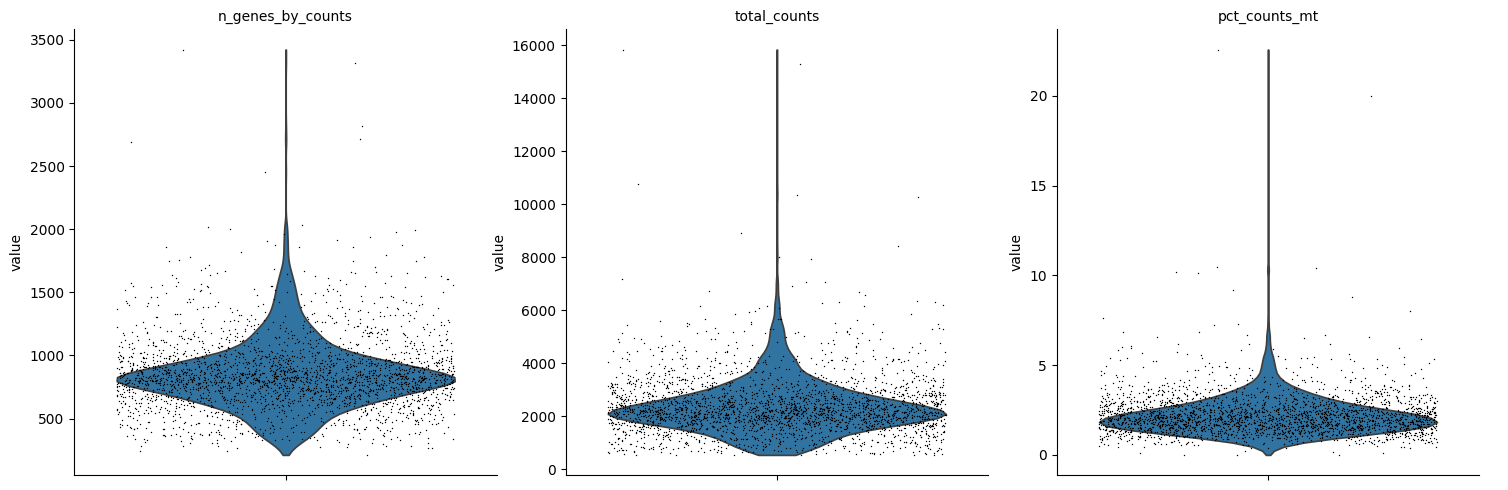

QC metrics calculated!
       n_genes_by_counts  total_counts  pct_counts_mt
count        2700.000000   2700.000000    2700.000000
mean          846.994074   2366.900391       2.215132
std           282.104964   1094.262085       1.165438
min           212.000000    548.000000       0.000000
25%           690.000000   1757.750000       1.536238
50%           817.000000   2197.000000       2.029639
75%           953.250000   2763.000000       2.640218
max          3422.000000  15844.000000      22.569027


In [3]:
import os
os.makedirs('outputs', exist_ok=True)

# Flag mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

# Visualize QC metrics
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    save='_qc_before_filtering.png'
)

print("QC metrics calculated!")
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())

In [4]:
# Filter low quality cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Remove cells with too many genes (doublets)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]

# Remove cells with high mitochondrial content (dying cells)
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"Cells remaining: {adata.n_obs}")
print(f"Genes remaining: {adata.n_vars}")

filtered out 19024 genes that are detected in less than 3 cells
Cells remaining: 2638
Genes remaining: 13714


In [5]:
# Normalize total counts per cell to 10,000
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform
sc.pp.log1p(adata)

# Save raw counts before further processing
adata.raw = adata

print("Normalization complete!")
print(adata)

normalizing counts per cell


C:\Users\HP\anaconda3\envs\scrna\lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:04)
Normalization complete!
AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'


extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


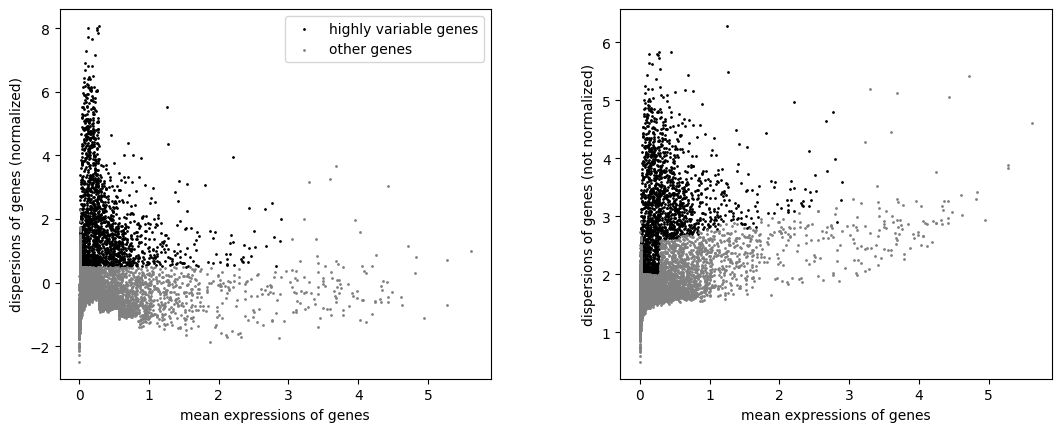

Highly variable genes: 1838


C:\Users\HP\anaconda3\envs\scrna\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\HP\anaconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Feature selection complete!
AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'


In [6]:
# Identify highly variable genes
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

# Visualize HVG selection
sc.pl.highly_variable_genes(adata, save='_hvg.png')

print(f"Highly variable genes: {adata.var.highly_variable.sum()}")

# Filter to HVGs only
adata = adata[:, adata.var.highly_variable]

# Scale data
sc.pp.scale(adata, max_value=10)

print("Feature selection complete!")
print(adata)


In [7]:
import os
os.makedirs('outputs', exist_ok=True)

# Export QC metrics
adata.obs.to_csv('outputs/qc_metrics.csv')

# Save final preprocessed AnnData
adata.write('outputs/preprocessed_adata.h5ad')

print("✅ Pre-processing complete!")
print(f"   Cells: {adata.n_obs}")
print(f"   Genes (HVG): {adata.n_vars}")
print("   Saved: outputs/preprocessed_adata.h5ad")
print("   Saved: outputs/qc_metrics.csv")

✅ Pre-processing complete!
   Cells: 2638
   Genes (HVG): 1838
   Saved: outputs/preprocessed_adata.h5ad
   Saved: outputs/qc_metrics.csv
